# Building and Evaluating Neural Network Classifiers on the Iris Dataset with TensorFlow/Keras 

# 1. Introduction 

The Iris dataset is a classic dataset in machine learning, consisting of 150 samples with four features each: sepal length, sepal width, petal length, and petal width. The goal is to classify each sample into one of three species of Iris: *Setosa*, *Versicolour*, or *Virginica*.

In this notebook, we will:

- Explore and preprocess the data.
- Build a neural network with Keras.
- Train and evaluate the model.
- Optimize the model for better performance.

## 1.1 Prerequisites

Before we begin, ensure that you have the following installed:

- **Python** (version 3.6 or higher)
- **Jupyter Notebook** or any other IDE (e.g., VS Code, PyCharm)
- Libraries:
  - `numpy`
  - `pandas`
  - `matplotlib`
  - `seaborn`
  - `scikit-learn`
  - `tensorflow` (which includes Keras)

You can install the necessary libraries using `pip`:

In [18]:
pip install numpy pandas matplotlib seaborn scikit-learn tensorflow jupyter scikeras

Note: you may need to restart the kernel to use updated packages.


# 2. Importing Libraries and Loading the Iris Dataset

Before diving into modeling, it's essential to understand the data's structure, distribution, and underlying patterns.

## 2.1 Importing Necessary Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For reproducibility
import random

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## 2.2 Loading the Dataset

Seaborn provides a convenient method to load the Iris dataset.

In [20]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(data=X, columns=iris.feature_names)
df['species'] = y

# Display the first five rows
df.head(20)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


# 3. Exploratory Data Analysis
Before building the model, it's essential to understand the data's distribution and relationships.

## 3.1 Distribution of Classes

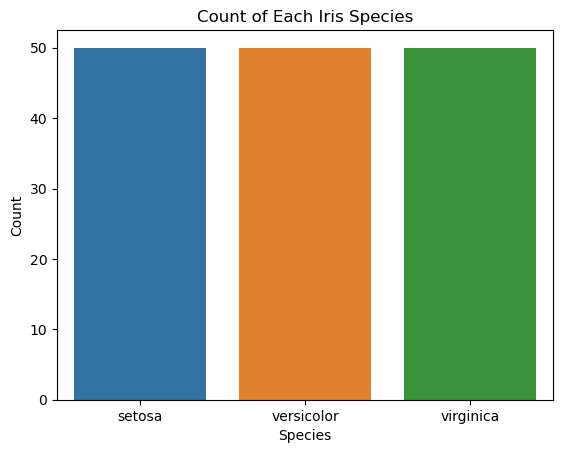

In [21]:
# Count of each species
sns.countplot(x='species', data=df)
plt.title('Count of Each Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(ticks=[0,1,2], labels=iris.target_names)
plt.show()

## 3.2 Pairplot 

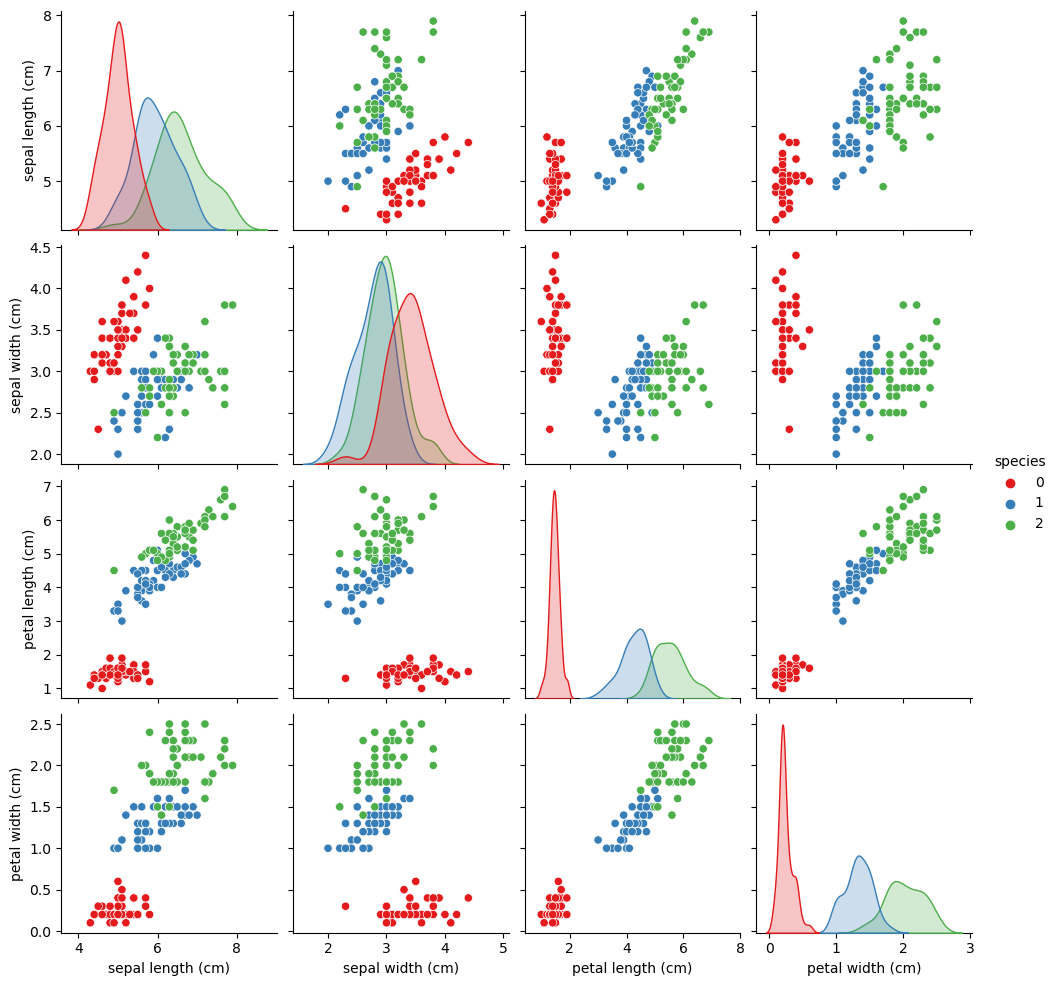

In [22]:
# Pairplot to visualize relationships
sns.pairplot(df, hue='species', vars=iris.feature_names, palette='Set1')
plt.show()

Observations:

Setosa is linearly separable from the other two species.
Versicolour and Virginica have overlapping features, making classification more challenging.

# 4. Data Preprocessing 

Proper preprocessing is crucial for the model's performance.

## 4.1 Feature Scaling
Neural networks perform better when input features are scaled. We'll use StandardScaler to standardize the features.

In [23]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

## 4.2 Train Test Split
We will split the data into training and testing sets to evaluate the model's performance on unseen data.


In [24]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 120
Testing samples: 30


# 5. Building the Neural Network

We will build a feedforward neural network using Keras' Sequential API.

## 5.1 Architecture Selection

Considerations:

- Input Layer: 4 neurons (one for each feature).

- Hidden Layers: Experiment with one or more hidden layers.

- Number of Neurons in Hidden Layers: Common practice is to use a number between the input and output layers. We'll start with 8 neurons.

- Activation Functions: ReLU for hidden layers and Softmax for the output layer.

- Output Layer: 3 neurons (one for each class) with Softmax activation.

## 5.2 Rationale:

A single hidden layer with 8 neurons provides sufficient capacity for this simple classification task.
ReLU activation helps in mitigating the vanishing gradient problem.

Softmax activation is suitable for multi-class classification.

In [25]:
# Define the model
def create_model(optimizer='adam', dense_units=8, activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Dense(dense_units, input_dim=4, activation=activation, kernel_initializer='he_uniform'))
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(int(dense_units * 0.75), activation=activation, kernel_initializer='he_uniform'))
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(3, activation='softmax'))
    
    # Compile the model
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    return model


# 6. Compiling the Model

Compiling configures the learning process.

- Loss Function: sparse_categorical_crossentropy since labels are integers.
- Optimizer: Adam optimizer is efficient and widely used.
- Metrics: Accuracy to monitor the training.

In [26]:
# Create the model
model = create_model()

# Summary of the model
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

### Explanation:

- First Dense Layer: 8 neurons with ReLU activation. Parameters: (4 input features * 8 neurons) + 8 biases = 40.
- Second Dense Layer: 6 neurons (75% of 8) with ReLU activation. Parameters: (8 * 6) + 6 = 54.
- Output Dense Layer: 3 neurons with Softmax activation. Parameters: (6 * 3) + 3 = 21.

Total Parameters: 40 + 54 + 21 = 115.


### Training the Model

We'll train the model using the training data and validate it on a validation split.

In [27]:
# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=500,
    batch_size=5,
    validation_split=0.1,
    verbose=1,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4387 - loss: 1.3167 - val_accuracy: 0.1667 - val_loss: 1.3284
Epoch 2/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4465 - loss: 1.1486 - val_accuracy: 0.1667 - val_loss: 1.1540
Epoch 3/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4235 - loss: 1.0089 - val_accuracy: 0.3333 - val_loss: 1.0141
Epoch 4/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5606 - loss: 0.8920 - val_accuracy: 0.8333 - val_loss: 0.9052
Epoch 5/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7400 - loss: 0.7955 - val_accuracy: 0.8333 - val_loss: 0.8198
Epoch 6/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8224 - loss: 0.7163 - val_accuracy: 0.8333 - val_loss: 0.7524
Epoch 7/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8449 - loss: 0.6506 - val_accuracy: 0.8333 - val_loss: 0.6995
Epoch 8/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8505 - loss: 0.5962 - val_accuracy: 0.8333 - v

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9542 - loss: 0.1398 - val_accuracy: 1.0000 - val_loss: 0.1353
Epoch 52/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9542 - loss: 0.1374 - val_accuracy: 1.0000 - val_loss: 0.1308
Epoch 53/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9542 - loss: 0.1344 - val_accuracy: 1.0000 - val_loss: 0.1261
Epoch 54/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9542 - loss: 0.1317 - val_accuracy: 1.0000 - val_loss: 0.1212
Epoch 55/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9542 - loss: 0.1291 - val_accuracy: 1.0000 - val_loss: 0.1166
Epoch 56/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9542 - loss: 0.1265 - val_accuracy: 1.0000 - val_loss: 0.1121
Epoch 57/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9542 - loss: 0.1241 - val_accuracy: 1.0000 - val_loss: 0.1075
Epoch 58/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9542 - loss: 0.1217 - val_accuracy: 1.0000 - val_lo

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9890 - loss: 0.0570 - val_accuracy: 1.0000 - val_loss: 0.0248
Epoch 102/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9890 - loss: 0.0562 - val_accuracy: 1.0000 - val_loss: 0.0242
Epoch 103/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9890 - loss: 0.0555 - val_accuracy: 1.0000 - val_loss: 0.0237
Epoch 104/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9890 - loss: 0.0548 - val_accuracy: 1.0000 - val_loss: 0.0232
Epoch 105/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9890 - loss: 0.0541 - val_accuracy: 1.0000 - val_loss: 0.0227
Epoch 106/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9890 - loss: 0.0535 - val_accuracy: 1.0000 - val_loss: 0.0222
Epoch 107/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9890 - loss: 0.0528 - val_accuracy: 1.0000 - val_loss: 0.0218
Epoch 108/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9890 - loss: 0.0521 - val_accuracy: 1.0000 -

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0330 - val_accuracy: 1.0000 - val_loss: 0.0133
Epoch 152/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0328 - val_accuracy: 1.0000 - val_loss: 0.0132
Epoch 153/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0325 - val_accuracy: 1.0000 - val_loss: 0.0132
Epoch 154/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9969 - loss: 0.0322 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 155/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0319 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 156/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0317 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 157/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0314 - val_accuracy: 1.0000 - val_loss: 0.0130
Epoch 158/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0312 - val_accuracy: 1.0000 -

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0250 - val_accuracy: 1.0000 - val_loss: 0.0117
Epoch 202/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0249 - val_accuracy: 1.0000 - val_loss: 0.0117
Epoch 203/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0248 - val_accuracy: 1.0000 - val_loss: 0.0118
Epoch 204/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0247 - val_accuracy: 1.0000 - val_loss: 0.0117
Epoch 205/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0246 - val_accuracy: 1.0000 - val_loss: 0.0116
Epoch 206/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0244 - val_accuracy: 1.0000 - val_loss: 0.0114
Epoch 207/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 0.0114
Epoch 208/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0241 - val_accuracy: 1.0000 -

### Early Stopping and Model Checkpointing
Early Stopping:

- Monitors validation loss.
- Stops training if validation loss does not improve for 10 consecutive epochs.
- Restores the best weights observed during training.

Model Checkpointing:

- Saves the model with the best validation loss.
- Useful for retrieving the best model after training.
- These techniques help in preventing overfitting and ensure that the model generalizes well to unseen data.

### Visualizing Training Progress

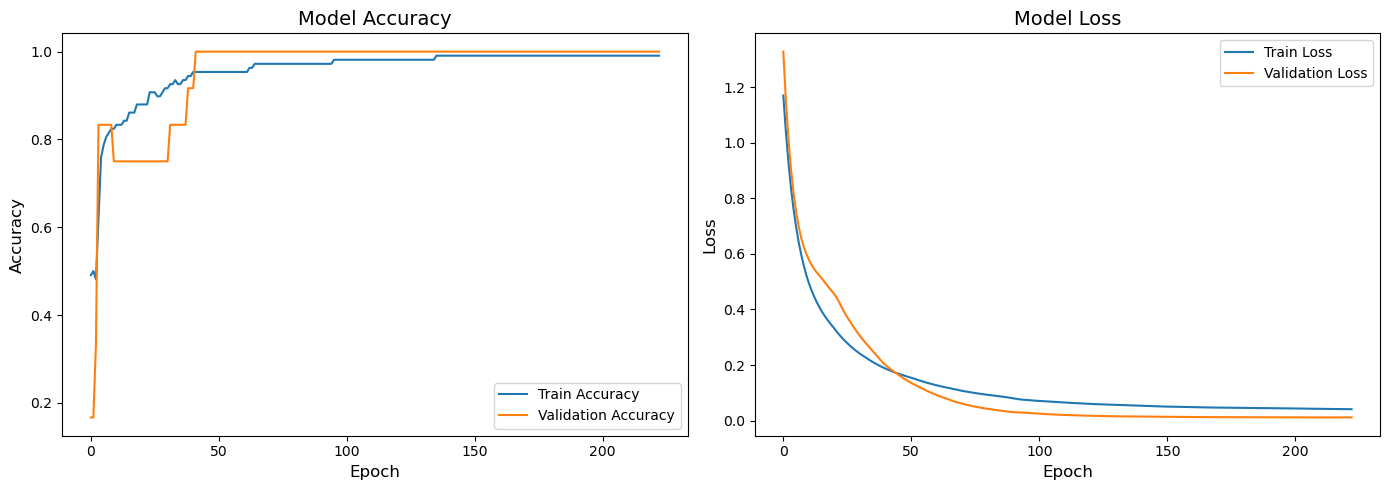

In [28]:
# Plot training & validation accuracy values
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=14)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


### Observations:

The model converges quickly within 50 epochs.
Training and validation accuracy stabilize, indicating good generalization.
Early stopping likely halted training before overfitting occurred.


# 6. Evaluating the Model
Let's evaluate the model's performance on the test set.

In [29]:
# Load the best model
best_model = tf.keras.models.load_model('best_model.keras')

# Evaluate on test data
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9667


## 6.1 Classification Report

In [30]:
# Predict classes
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=iris.target_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 6.2 Confusion Matrix 

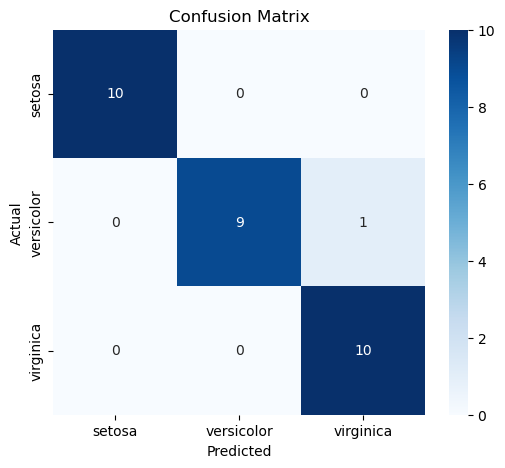

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


Performance Metrics:

Accuracy: 96.7%
Precision, Recall, F1-Score: Perfect scores for all classes except versicolor, indicating excellent performance. One versicolor is misclassified as virginicia. 

## 6.3 Cross validation

In [50]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Define a KerasClassifier wrapper
model = KerasClassifier(model=create_model, epochs=150, batch_size=5, verbose=0)

# Define cross-validation strategy
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate model
cv_results = cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')

print(f"Cross-Validation Accuracy: {cv_results.mean():.4f} ± {cv_results.std():.4f}")

Cross-Validation Accuracy: 0.9400 ± 0.0646


# 7. Topic 1: Exploring Different Non-linearities

## 7.1 Activation Functions to Explore

We'll consider the following activation functions:

- ReLU (Rectified Linear Unit)
- Sigmoid
- Tanh
- Leaky ReLU
- ELU (Exponential Linear Unit)

These activation functions are widely used in various neural network architectures due to their unique properties.

## 7.2 Modifying the Model Creation Function

First, we'll update the create_model function to handle different activation functions, including those that require additional parameters (e.g., Leaky ReLU and ELU).


In [52]:
from tensorflow.keras.layers import LeakyReLU, ELU

def create_model(optimizer='adam', dense_units=8, activation='relu', dropout_rate=0.0):
    model = Sequential()
    # First Dense Layer
    model.add(Dense(dense_units, input_dim=4, kernel_initializer='he_uniform'))
    
    # Activation Layer
    if activation == 'leaky_relu':
        model.add(LeakyReLU(alpha=0.1))
    elif activation == 'elu':
        model.add(ELU(alpha=1.0))
    else:
        model.add(tf.keras.layers.Activation(activation))
    
    # Dropout (if any)
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))
    
    # Second Dense Layer
    model.add(Dense(int(dense_units * 0.75), kernel_initializer='he_uniform'))
    
    # Activation Layer for Second Dense Layer
    if activation == 'leaky_relu':
        model.add(LeakyReLU(alpha=0.1))
    elif activation == 'elu':
        model.add(ELU(alpha=1.0))
    else:
        model.add(tf.keras.layers.Activation(activation))
    
    # Dropout (if any)
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))
    
    # Output Layer
    model.add(Dense(3, activation='softmax'))
    
    # Compile the model
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    return model


## 7.3 Training Models with Different Activation Functions

We'll define a list of activation functions to explore and train a separate model for each. We'll store their training histories and final test accuracies for comparison.


In [54]:
# Define the activation functions to explore
activation_functions = ['relu', 'sigmoid', 'tanh', 'leaky_relu', 'elu']

# Dictionary to store histories and test accuracies
histories = {}
test_accuracies = {}

# Iterate over each activation function
for activation in activation_functions:
    print(f"\nTraining model with {activation} activation:")
    
    # Create a new model instance
    model = create_model(activation=activation, dropout_rate=0.2)
    
    # Define callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    checkpoint = ModelCheckpoint(f'best_model_{activation}.keras', monitor='val_loss', save_best_only=True)
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=500,
        batch_size=5,
        validation_split=0.1,
        verbose=0,
        callbacks=[early_stop, checkpoint]
    )
    
    # Load the best model
    best_model = tf.keras.models.load_model(f'best_model_{activation}.keras')
    
    # Evaluate on test data
    test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
    test_accuracies[activation] = test_accuracy
    histories[activation] = history
    
    print(f"Test Accuracy with {activation}: {test_accuracy:.4f}")



Training model with relu activation:
Test Accuracy with relu: 0.9333

Training model with sigmoid activation:
Test Accuracy with sigmoid: 0.9667

Training model with tanh activation:
Test Accuracy with tanh: 0.9333

Training model with leaky_relu activation:
Test Accuracy with leaky_relu: 0.9333

Training model with elu activation:
Test Accuracy with elu: 0.9333


## 7.4 Visualizing Training Progress for Each Activation Function
To compare how each activation function affects training dynamics, we'll plot the training and validation accuracy and loss curves.

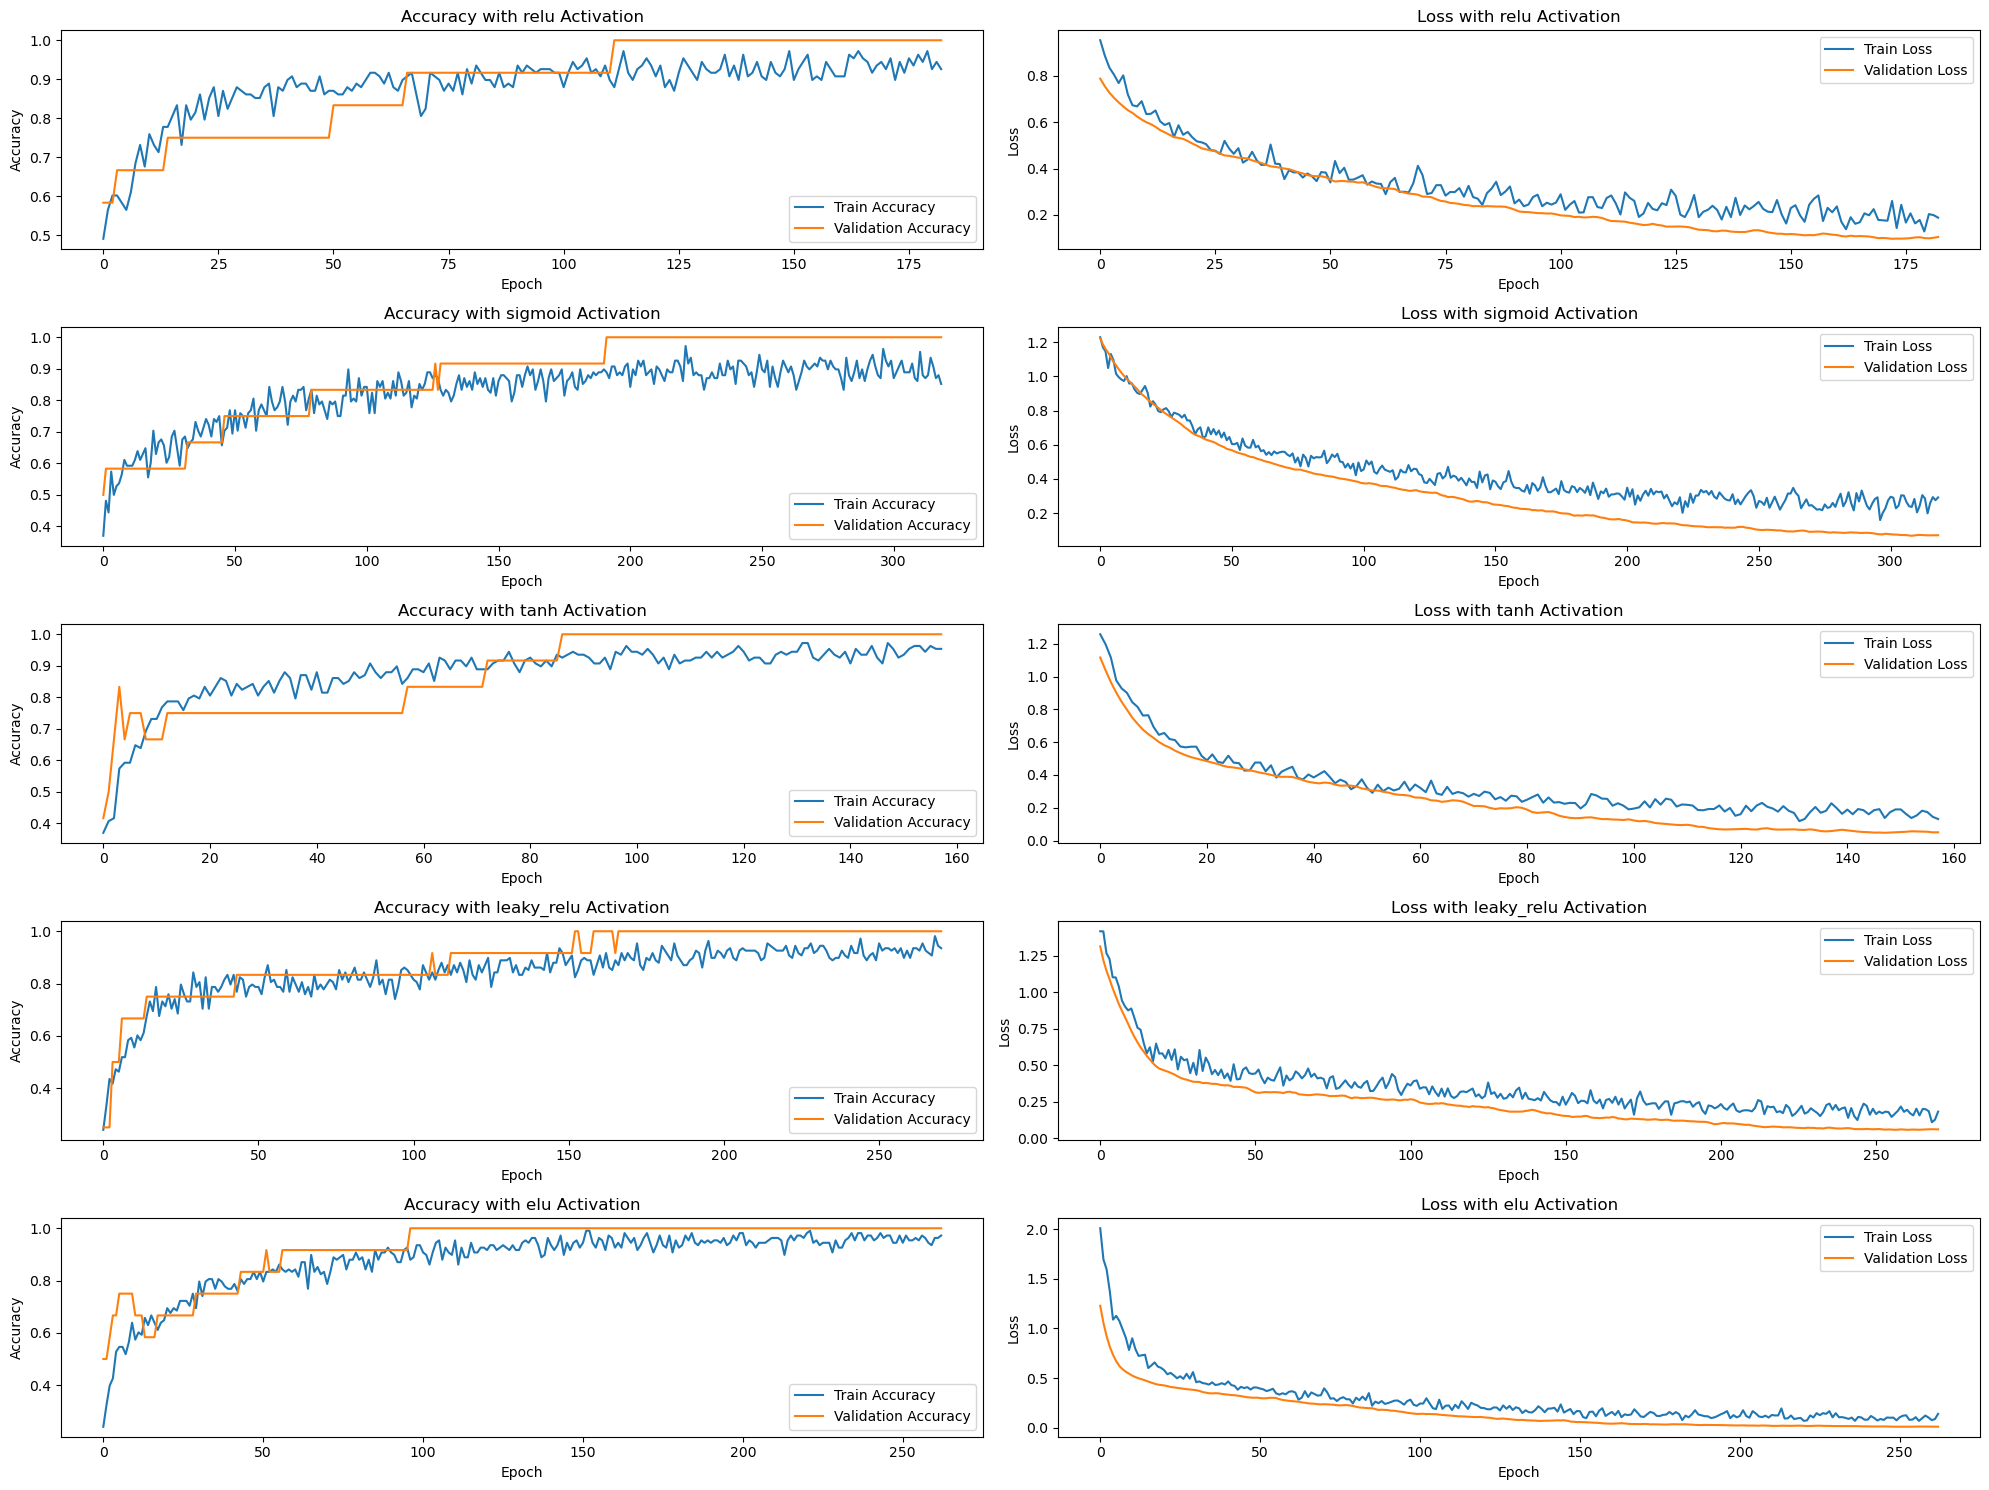

In [55]:
# Set up the plotting area
plt.figure(figsize=(20, 15))

for idx, activation in enumerate(activation_functions):
    history = histories[activation]
    
    # Plot Accuracy
    plt.subplot(len(activation_functions), 2, 2*idx + 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy with {activation} Activation', fontsize=12)
    plt.xlabel('Epoch', fontsize=10)
    plt.ylabel('Accuracy', fontsize=10)
    plt.legend(loc='lower right')
    
    # Plot Loss
    plt.subplot(len(activation_functions), 2, 2*idx + 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss with {activation} Activation', fontsize=12)
    plt.xlabel('Epoch', fontsize=10)
    plt.ylabel('Loss', fontsize=10)
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


# 8. Topic 2: Contrasting Different Machine Learning Algorithms: Neural Network vs. K-Means Clustering

In machine learning, various algorithms can be employed to tackle the same problem, each with its unique approach and underlying assumptions. In this section, we'll contrast two distinct machine learning algorithms—a Neural Network (a supervised learning method) and K-Means Clustering (an unsupervised learning method)—to understand how they perform on the Iris dataset.

## 8.1 Applying Neural Network and K-Means Clustering to the Iris Dataset
We'll apply both algorithms to the Iris dataset and compare their performances based on classification accuracy and visualization.

We'll use the best-performing Neural Network model from the previous sections, which achieved a test accuracy of 96.67%.

## 8.2 K-Means Clustering Implementation

### 8.2.1 Applying k-means clustering

In [58]:
from sklearn.cluster import KMeans
from scipy.stats import mode

# Initialize K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit K-Means on the scaled data
kmeans.fit(X_scaled)

# Predict cluster assignments
clusters = kmeans.labels_

### 8.2.2 Mapping clusters to labels

In [59]:
# Create a DataFrame to compare clusters and true labels
df_clusters = pd.DataFrame({'Cluster': clusters, 'True Label': y})

# Map each cluster to the most frequent true label
cluster_mapping = df_clusters.groupby('Cluster')['True Label'].agg(lambda x: mode(x)[0]).to_dict()

print("Cluster to Class Mapping:")
for cluster, label in cluster_mapping.items():
    print(f"Cluster {cluster}: {iris.target_names[label]}")


Cluster to Class Mapping:
Cluster 0: virginica
Cluster 1: setosa
Cluster 2: setosa


### 8.2.3 Assigning predicated labels based on cluster mapping

In [60]:
# Assign predicted labels based on cluster mapping
y_pred_kmeans = np.array([cluster_mapping[cluster] for cluster in clusters])

# Calculate accuracy
accuracy_kmeans = accuracy_score(y, y_pred_kmeans)
print(f"K-Means Clustering Accuracy: {accuracy_kmeans:.4f}")


K-Means Clustering Accuracy: 0.6667


### 8.3 Evaluate K-means performance

To better understand how K-Means clusters the data, we'll visualize the clusters using Principal Component Analysis (PCA) to reduce the feature dimensions to two.


K-Means Clustering Accuracy: 0.6667

K-Means Clustering Classification Report:
              precision    recall  f1-score   support

      setosa       0.93      1.00      0.96        50
  versicolor       0.00      0.00      0.00        50
   virginica       0.52      1.00      0.68        50

    accuracy                           0.67       150
   macro avg       0.48      0.67      0.55       150
weighted avg       0.48      0.67      0.55       150



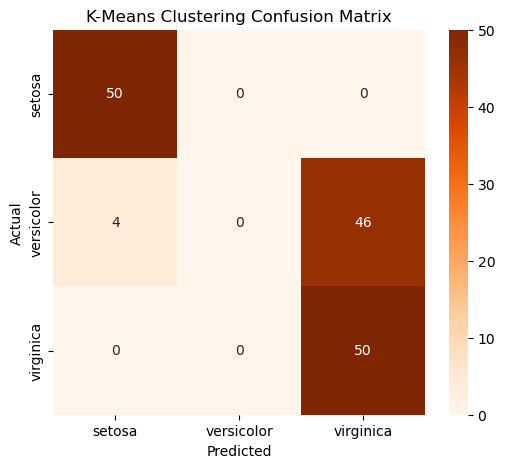

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Calculate accuracy
accuracy_kmeans = accuracy_score(y, y_pred_kmeans)
print(f"K-Means Clustering Accuracy: {accuracy_kmeans:.4f}")

# Classification Report
print("\nK-Means Clustering Classification Report:")
print(classification_report(y, y_pred_kmeans, target_names=iris.target_names))

# Confusion Matrix
cm_kmeans = confusion_matrix(y, y_pred_kmeans)
plt.figure(figsize=(6,5))
sns.heatmap(cm_kmeans, annot=True, fmt='d', cmap='Oranges',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('K-Means Clustering Confusion Matrix')
plt.show()


### Interpretation 

K-means found one very clean cluster for setosa but did not distinguish well between versicolor and virginica. In this particular run, it effectively treated those two species as one group.
This result is not unexpected. Setosa is quite distinct, while versicolor and virginica are more similar to each other in the feature space, making it harder for K-means to separate them into distinct clusters without supervision.